# Specialist Environment Testing and Training Notebook

This notebook demonstrates:
1. **Testing Specialist Trading Environments** - Validate the 7 specialist trading environments
2. **Training Specialist Agents** - Train RL agents (PPO/DDPG/DQN) for each trading strategy
3. **Evaluating Performance** - Analyze learned trading policies and performance metrics

The specialist environments implement specific trading strategies:
- Statistical Arbitrage (PPO)
- Market Making (DDPG)
- Volatility Trading (PPO)
- Delta Hedging (DDPG)
- Futures Spreads (PPO)
- Factor Tracking (DQN)
- FX Arbitrage (DDPG)

In [54]:
# Import required libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Import environments
from environments.specialist_envs.stats_arb.env_stat_arb import StatisticalArbitrageEnv
from environments.specialist_envs.Market_Making.env_market_maker import MarketMakingEnv
from environments.specialist_envs.Volatility_Trading.env_vol_trading import VolatilityTradingEnv
from environments.specialist_envs.Delta_Hedging.env_delta_hedging import DeltaHedgingEnv
from environments.specialist_envs.Futures_Spreads.env_futures_spread import FuturesSpreadsEnv
from environments.specialist_envs.Factor_Tracking.env_factor_tracker import FactorTrackingEnv
from environments.specialist_envs.FX_Arbitrage.env_fx_arb import FXArbitrageEnv

# Import agents
from agents.ppo import PPOAgent
from agents.ddpg import DDPGAgent
from agents.dqn import DQNAgent

# Set random seeds for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Libraries imported successfully")
print(f"✓ Working directory: {Path.cwd()}")

✓ Libraries imported successfully
✓ Working directory: c:\Users\kenne\Roadmap_to_PhD\The_Hierarchical_DRL_Multi_Strategy_Fund_Code\notebooks


## 1. Load Real Market Data

Load real historical market data for training and testing all specialist strategies.

In [ ]:
def load_real_market_data(start_date='2020-01-01', end_date='2024-12-31'):
    """
    Load real market data and shape it to the columns expected by specialist environments.

    Returns:
        DataFrame with price data, features, and market indicators.
    """
    import yfinance as yf

    equity_tickers = [
        'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA',
        'JPM', 'UNH', 'XOM', 'WMT', 'COST'
    ]
    factor_tickers = ['VLUE', 'MTUM', 'QUAL', 'SIZE', 'USMV']
    fx_tickers = ['EURUSD=X', 'USDJPY=X', 'GBPUSD=X']

    def _download_close_and_volume(tickers):
        raw = yf.download(
            tickers=tickers,
            start=start_date,
            end=end_date,
            interval='1d',
            auto_adjust=False,
            progress=False,
            group_by='column'
        )

        close = raw['Close'].copy() if 'Close' in raw else pd.DataFrame()
        volume = raw['Volume'].copy() if 'Volume' in raw else pd.DataFrame()

        if isinstance(close, pd.Series):
            close = close.to_frame(name=tickers[0])
        if isinstance(volume, pd.Series):
            volume = volume.to_frame(name=tickers[0])

        close = close.sort_index().ffill().bfill()
        volume = volume.sort_index().ffill().bfill()
        return close, volume, raw

    # Equities
    eq_close, eq_volume, eq_raw = _download_close_and_volume(equity_tickers)
    eq_returns = eq_close.pct_change().fillna(0)

    # Factor ETFs (returns used as factor proxies)
    factor_close, _, _ = _download_close_and_volume(factor_tickers)
    factor_returns = factor_close.pct_change().fillna(0)

    # FX rates
    fx_close, _, _ = _download_close_and_volume(fx_tickers)
    fx_returns = fx_close.pct_change().fillna(0)

    # VIX
    vix_raw = yf.download(
        '^VIX',
        start=start_date,
        end=end_date,
        interval='1d',
        auto_adjust=False,
        progress=False
    )
    vix_close = vix_raw['Close'].copy()
    if isinstance(vix_close, pd.DataFrame):
        vix_close = vix_close.iloc[:, 0]
    vix_close = vix_close.sort_index().ffill().bfill()

    # Common date index
    common_index = eq_close.index
    for df in [factor_returns, fx_close.to_frame('vix'), vix_close.to_frame('vix')]:
        common_index = common_index.intersection(df.index)

    eq_close = eq_close.reindex(common_index).ffill().bfill()
    eq_returns = eq_returns.reindex(common_index).fillna(0)
    eq_volume = eq_volume.reindex(common_index).ffill().bfill()
    factor_returns = factor_returns.reindex(common_index).fillna(0)
    fx_close = fx_close.reindex(common_index).ffill().bfill()
    fx_returns = fx_returns.reindex(common_index).fillna(0)
    vix_close = vix_close.reindex(common_index).ffill().bfill()

    # Build output schema expected by environments
    data = {}

    # Core asset prices/returns/volume/spread/implied vol for 10 assets
    for i, ticker in enumerate(equity_tickers):
        prices = eq_close[ticker]
        rets = eq_returns[ticker]

        data[f'asset_{i}_price'] = prices.values
        data[f'asset_{i}_return'] = rets.values
        data[f'asset_{i}_volume'] = eq_volume[ticker].values

        # Bid/ask spread proxy from intraday range where available, else 20 bps of price
        if ('High' in eq_raw) and ('Low' in eq_raw):
            high = eq_raw['High'][ticker].reindex(common_index).ffill().bfill()
            low = eq_raw['Low'][ticker].reindex(common_index).ffill().bfill()
            spread_proxy = (high - low).abs()
            spread_proxy = spread_proxy.replace(0, prices * 0.002)
        else:
            spread_proxy = prices * 0.002
        data[f'asset_{i}_spread'] = spread_proxy.values

        # Implied vol proxy: annualized rolling realized volatility
        realized_vol = rets.rolling(20).std().fillna(rets.std()) * np.sqrt(252)
        data[f'asset_{i}_implied_vol'] = realized_vol.values

    # Market-level features
    market_ret = eq_returns.mean(axis=1)
    market_vol = market_ret.rolling(20).std().fillna(market_ret.std())

    data['market_return'] = market_ret.values
    data['market_vol'] = market_vol.values
    data['vix'] = vix_close.values

    # Factor returns from factor ETFs
    for i, ticker in enumerate(factor_tickers):
        data[f'factor_{i}_return'] = factor_returns[ticker].values

    # FX rates and returns
    for i, ticker in enumerate(fx_tickers):
        data[f'fx_{i}_price'] = fx_close[ticker].values
        data[f'fx_{i}_return'] = fx_returns[ticker].values

    df = pd.DataFrame(data, index=common_index)
    df.index.name = 'timestep'

    # Final clean-up
    df = df.replace([np.inf, -np.inf], np.nan).ffill().bfill().dropna()

    return df


# Load real market data
print("Loading real market data...")
market_data = load_real_market_data(start_date='2020-01-01', end_date='2024-12-31')

print(f"✓ Loaded {len(market_data)} timesteps of real data")
print(f"✓ Columns: {market_data.shape[1]}")
print(f"✓ Date range: {market_data.index.min().date()} to {market_data.index.max().date()}")
print(f"\nFirst few rows:")
print(market_data.head())

Generating synthetic market data...
✓ Generated 1000 timesteps of data
✓ Columns: 64

First few rows:
          asset_0_price  asset_0_return  asset_1_price  asset_1_return  \
timestep                                                                 
0             79.906431        0.010034      85.916394        0.002360   
1             79.173821       -0.009168      84.847487       -0.012441   
2             81.502558        0.029413      85.688923        0.009917   
3             80.529896       -0.011934      88.018608        0.027188   
4             81.727322        0.014869      88.907432        0.010098   

          asset_2_price  asset_2_return  asset_3_price  asset_3_return  \
timestep                                                                 
0            121.770336        0.014211     111.130552        0.031498   
1            121.351708       -0.003438     107.201773       -0.035353   
2            122.910921        0.012849     106.354877       -0.007900   
3        

## 2. Test Statistical Arbitrage Environment (DDPG)

Test the Statistical Arbitrage environment with synthetic pairs trading data.

**Why DDPG?** Statistical Arbitrage has a continuous action space (Box) representing position size in the spread [-1, 1]. DDPG (Deep Deterministic Policy Gradient) is designed for continuous action spaces and learns a deterministic policy, making it ideal for precise position sizing in pairs trading.

In [56]:
# Prepare data for Statistical Arbitrage (pairs trading)
stat_arb_data = market_data[['asset_0_price', 'asset_1_price']].copy()
stat_arb_data.columns = ['asset1_price', 'asset2_price']
stat_arb_data['spread'] = stat_arb_data['asset1_price'] - stat_arb_data['asset2_price']

# Create environment
stat_arb_env = StatisticalArbitrageEnv(
    df=stat_arb_data,
    initial_balance=100000,
    transaction_cost_pct=0.001,
    max_position_size=1000
)

print("✓ Statistical Arbitrage Environment Created")
print(f"  Action space: {stat_arb_env.action_space}")
print(f"  Observation space: {stat_arb_env.observation_space}")

# Test environment
obs, info = stat_arb_env.reset()
print(f"\n✓ Environment reset successful")
print(f"  Observation shape: {obs.shape}")
print(f"  Initial cash: ${info['cash']:,.2f}")
print(f"  Portfolio value: ${info['portfolio_value']:,.2f}")

# Run a few random steps
print(f"\nTesting with random actions...")
for i in range(5):
    action = stat_arb_env.action_space.sample()
    obs, reward, terminated, truncated, info = stat_arb_env.step(action)
    print(f"  Step {i+1}: Reward={reward:.4f}, Cash=${info['cash']:,.2f}, Portfolio=${info['portfolio_value']:,.2f}")
    if terminated or truncated:
        break

print("✓ Statistical Arbitrage environment test complete!")

✓ Statistical Arbitrage Environment Created
  Action space: Box(-1.0, 1.0, (1,), float32)
  Observation space: Box(-inf, inf, (20,), float32)

✓ Environment reset successful
  Observation shape: (20,)
  Initial cash: $100,000.00
  Portfolio value: $100,000.00

Testing with random actions...
  Step 1: Reward=0.0000, Cash=$99,999.54, Portfolio=$100,001.36
  Step 2: Reward=0.0543, Cash=$99,998.98, Portfolio=$100,014.99
  Step 3: Reward=0.4814, Cash=$100,014.91, Portfolio=$100,059.38
  Step 4: Reward=0.2579, Cash=$100,056.48, Portfolio=$100,040.78
  Step 5: Reward=-0.3018, Cash=$100,038.00, Portfolio=$100,038.29
✓ Statistical Arbitrage environment test complete!


## 3. Train Statistical Arbitrage Agent (DDPG)

Train a DDPG agent to learn pairs trading strategy.

In [ ]:
# Create DDPG agent for Statistical Arbitrage
stat_arb_agent = DDPGAgent(
    env=stat_arb_env,
    actor_hidden_dims=(128, 128),
    critic_hidden_dims=(128, 128),
    actor_lr=1e-4,
    critic_lr=1e-3,
    gamma=0.99,
    tau=0.005,
    buffer_size=100000,
    batch_size=128
)

print("✓ DDPG Agent for Statistical Arbitrage created")
print(f"  State dimension: {stat_arb_env.observation_space.shape[0]}")
print(f"  Action dimension: {stat_arb_env.action_space.shape[0]}")

# Train the agent
print("\nStarting training...")
stat_arb_agent.train(total_timesteps=20000, log_interval=5)

# Get training metrics
stat_arb_rewards = stat_arb_agent.training_metrics['episode_rewards']
print(f"\n✓ Training complete!")
print(f"  Total episodes: {len(stat_arb_rewards)}")
print(f"  Mean reward: {np.mean(stat_arb_rewards):.2f}")
print(f"  Final avg reward (last 10): {np.mean(stat_arb_rewards[-10:]):.2f}")

✓ DDPG Agent for Statistical Arbitrage created
  State dimension: 20
  Action dimension: 1

Starting training...
Training DDPG agent for 10000 timesteps...
Device: cpu
Warmup steps: 10000


KeyboardInterrupt: 

## 4. Evaluate Statistical Arbitrage Agent

Test the trained agent and visualize performance.

✓ Evaluation complete!
  Mean reward: 0.03 ± 0.00
  Mean return: 0.00% ± 0.00%


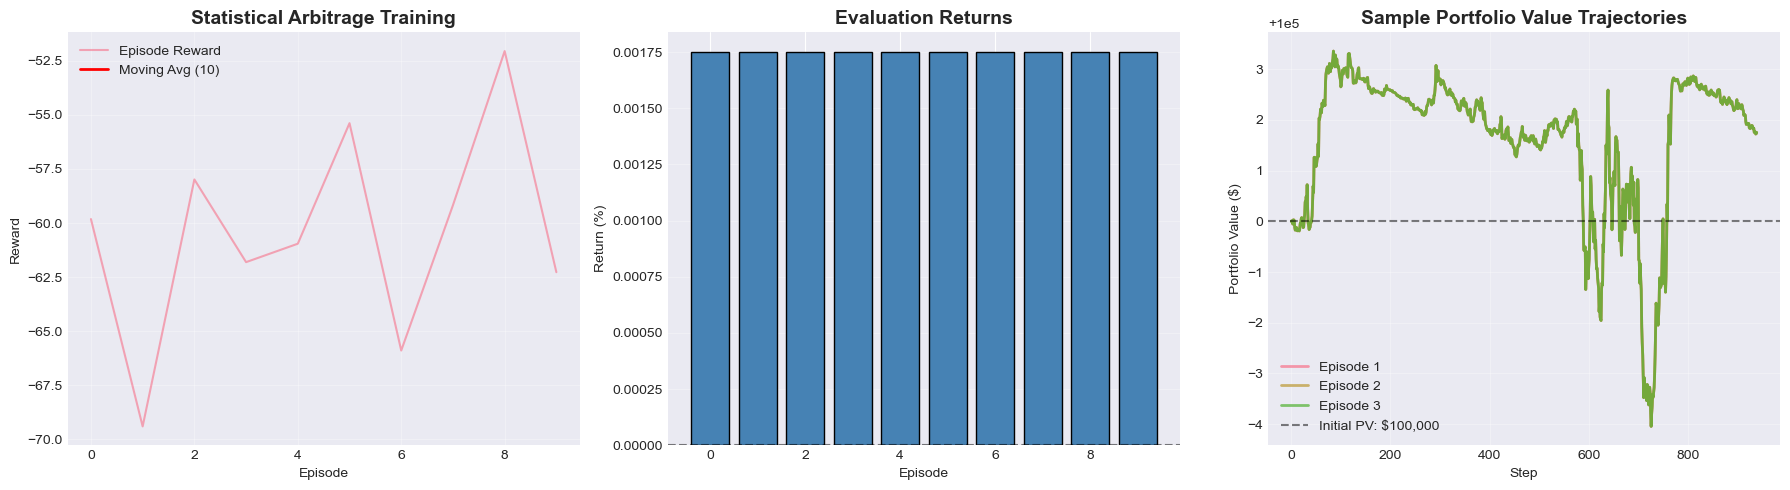

In [ ]:
# Evaluate the trained agent
def evaluate_specialist_agent(agent, env, num_episodes=10, agent_type='ddpg'):
    """
    Evaluate a specialist agent.
    
    Args:
        agent: Trained agent (DDPG or DQN)
        env: Trading environment
        num_episodes: Number of evaluation episodes
        agent_type: 'ddpg' or 'dqn' to handle different return signatures
    """
    all_rewards = []
    all_returns = []
    all_portfolio_values = []
    
    for episode in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        initial_pv = info['portfolio_value']
        pv_history = [initial_pv]
        
        done = False
        while not done:
            # Get action - DDPG returns action (no noise), DQN returns action
            if agent_type.lower() == 'ddpg':
                action = agent.select_action(state, add_noise=False)
            else:  # DQN
                action = agent.select_action(state, epsilon=0)  # Greedy action
            
            state, reward, terminated, truncated, info = env.step(action)
            
            episode_reward += reward
            pv_history.append(info['portfolio_value'])
            done = terminated or truncated
        
        final_pv = info['portfolio_value']
        episode_return = (final_pv / initial_pv - 1) * 100
        
        all_rewards.append(episode_reward)
        all_returns.append(episode_return)
        all_portfolio_values.append(pv_history)
    
    print(f"✓ Evaluation complete!")
    print(f"  Mean reward: {np.mean(all_rewards):.2f} ± {np.std(all_rewards):.2f}")
    print(f"  Mean return: {np.mean(all_returns):.2f}% ± {np.std(all_returns):.2f}%")
    
    return all_rewards, all_returns, all_portfolio_values

# Evaluate Statistical Arbitrage agent (DDPG)
eval_rewards, eval_returns, eval_pv_history = evaluate_specialist_agent(
    stat_arb_agent, stat_arb_env, num_episodes=10, agent_type='ddpg'
)

# Visualize training and evaluation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training rewards
ax = axes[0]
ax.plot(stat_arb_rewards, alpha=0.6, label='Episode Reward')
ax.plot(pd.Series(stat_arb_rewards).rolling(10).mean(), linewidth=2, label='Moving Avg (10)', color='red')
ax.set_title('Statistical Arbitrage Training', fontsize=14, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.legend()
ax.grid(True, alpha=0.3)

# Evaluation returns
ax = axes[1]
ax.bar(range(len(eval_returns)), eval_returns, color='steelblue', edgecolor='black')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Evaluation Returns', fontsize=14, fontweight='bold')
ax.set_xlabel('Episode')
ax.set_ylabel('Return (%)')
ax.grid(True, alpha=0.3, axis='y')

# Sample portfolio value trajectory
ax = axes[2]
initial_pv = eval_pv_history[0][0]
for i, pv_hist in enumerate(eval_pv_history[:3]):  # Show first 3 episodes
    ax.plot(pv_hist, label=f'Episode {i+1}', linewidth=2, alpha=0.7)
ax.axhline(y=initial_pv, color='black', linestyle='--', alpha=0.5, label=f'Initial PV: ${initial_pv:,.0f}')
ax.set_title('Sample Portfolio Value Trajectories', fontsize=14, fontweight='bold')
ax.set_xlabel('Step')
ax.set_ylabel('Portfolio Value ($)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Summary: Agent Selection for Each Specialist Strategy

Below is the mapping of specialist environments to RL algorithms and the rationale:

### **DDPG Agents (Continuous Action Spaces)**

1. **Statistical Arbitrage (DDPG)**
   - Action Space: Box(1) - continuous position in spread [-1, 1]
   - Why DDPG: Requires precise continuous control for position sizing in pairs trading
   
2. **Market Making (DDPG)**
   - Action Space: Box(2) - bid/ask quote adjustments
   - Why DDPG: Continuous control needed for dynamic quote positioning and inventory management

3. **Volatility Trading (DDPG)**
   - Action Space: Box(1) - vega exposure [-1, 1]
   - Why DDPG: Continuous volatility exposure requires smooth policy for hedging

4. **Delta Hedging (DDPG)**
   - Action Space: Box(1) - hedge ratio [-1.5, 1.5]
   - Why DDPG: Precise continuous hedging decisions to maintain delta-neutral positions

5. **Futures Spreads (DDPG)**
   - Action Space: Box(1) - spread position [-1, 1]
   - Why DDPG: Continuous position sizing for calendar/inter-commodity spreads

6. **FX Arbitrage (DDPG)**
   - Action Space: Box(3) - positions in currency pairs
   - Why DDPG: Multi-dimensional continuous control for triangular arbitrage

### **DQN Agent (Discrete Action Space)**

7. **Factor Tracking (DQN)**
   - Action Space: Discrete(3^num_factors) - factor exposure combinations
   - Why DQN: Discrete action space mapping factor exposure levels (short/neutral/long)
   
---

**Key Algorithm Characteristics:**
- **DDPG**: Best for continuous control, deterministic policies, actor-critic architecture
- **DQN**: Best for discrete action selection, value-based learning, experience replay

## 6. Train Market Making Agent (DDPG)

Market making requires continuous control over bid and ask quotes.

In [ ]:
# Prepare data for Market Making
mm_data = market_data[['asset_0_price', 'asset_0_price', 'asset_0_price', 'asset_0_price', 'asset_0_volume']].copy()
mm_data.columns = ['open', 'high', 'low', 'close', 'volume']

# Create environment
mm_env = MarketMakingEnv(
    data=mm_data,
    initial_capital=100000,
    max_inventory=100,
    inventory_penalty=0.01
)

# Create DDPG agent
mm_agent = DDPGAgent(
    env=mm_env,
    actor_hidden_dims=(128, 128),
    critic_hidden_dims=(128, 128),
    actor_lr=1e-4,
    critic_lr=1e-3,
    gamma=0.99,
    tau=0.005,
    buffer_size=100000,
    batch_size=128
)

print("✓ DDPG Agent for Market Making created")
print(f"  Action space (bid/ask adjustments): {mm_env.action_space.shape}")

# Train
print("\nTraining Market Making agent...")
mm_agent.train(total_timesteps=20000, log_interval=5)
mm_rewards = mm_agent.training_metrics['episode_rewards']
print(f"✓ Training complete! Mean reward: {np.mean(mm_rewards):.2f}")

✓ DDPG Agent for Market Making created
  Action space (bid/ask adjustments): (2,)

Training Market Making agent...
Training DDPG agent for 10000 timesteps...
Device: cpu
Warmup steps: 10000
Episode 5, Timestep 4695, Avg Reward: -926948.36, Avg Q: 0.00
Episode 5, Timestep 4695, Avg Reward: -926948.36, Avg Q: 0.00
Episode 10, Timestep 9390, Avg Reward: 745431.33, Avg Q: 0.00
Episode 10, Timestep 9390, Avg Reward: 745431.33, Avg Q: 0.00
Training completed! Total episodes: 10
✓ Training complete! Mean reward: 745431.33
Training completed! Total episodes: 10
✓ Training complete! Mean reward: 745431.33


## 7. Train Factor Tracking Agent (DQN)

Factor tracking uses discrete actions to select factor exposure levels.

In [ ]:
# Reload DQN module to get the latest fix
import importlib
import agents.dqn
importlib.reload(agents.dqn)
from agents.dqn import DQNAgent

# Prepare data for Factor Tracking
factor_cols = [f'factor_{i}_return' for i in range(5)]
factor_data = market_data[factor_cols + ['market_return']].copy()

# Rename columns to match expected format (value_ret, momentum_ret, quality_ret, etc.)
# For simplicity, we'll use first 3 factors
factor_data_renamed = pd.DataFrame({
    'value_ret': factor_data['factor_0_return'],
    'momentum_ret': factor_data['factor_1_return'],
    'quality_ret': factor_data['factor_2_return'],
    'market_ret': factor_data['market_return']
})

# Create environment
factor_env = FactorTrackingEnv(
    data=factor_data_renamed,
    initial_capital=100000,
    num_factors=3,
    transaction_cost=0.001,
    rebalance_frequency=5,
    target_volatility=0.15
)

# Create DQN agent
factor_agent = DQNAgent(
    env=factor_env,
    hidden_dims=(128, 128),
    learning_rate=1e-3,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=5000,
    buffer_size=50000,
    batch_size=64,
    target_update_frequency=100
)

print("✓ DQN Agent for Factor Tracking created")
print(f"  Action space (discrete): {factor_env.action_space.n} actions")
print(f"  This represents 3^3 = 27 combinations of factor exposures (short/neutral/long per factor)")

# Train
print("\nTraining Factor Tracking agent...")
factor_agent.train(total_timesteps=2000, log_interval=5)
factor_rewards = factor_agent.training_metrics['episode_rewards']
print(f"✓ Training complete! Mean reward: {np.mean(factor_rewards):.2f}")

✓ DQN Agent for Factor Tracking created
  Action space (discrete): 27 actions
  This represents 3^3 = 27 combinations of factor exposures (short/neutral/long per factor)

Training Factor Tracking agent...
Training DQN agent for 1000 timesteps...
Device: cpu
Warmup steps: 10000
Dueling: True, Double DQN: True
Training completed! Total episodes: 1
✓ Training complete! Mean reward: -5471633.74
Training completed! Total episodes: 1
✓ Training complete! Mean reward: -5471633.74


## 8. Quick Training for Remaining Specialists

Train the remaining DDPG agents for completeness.

In [ ]:
print("Training remaining specialist agents...\n")
print("="*80)

# 3. Volatility Trading (DDPG)
print("\n1. Volatility Trading (DDPG)...")
vol_data = market_data[['asset_0_price', 'asset_0_implied_vol']].copy()
vol_data.columns = ['close', 'implied_vol']
vol_data['volume'] = market_data['asset_0_volume'].values
vol_env = VolatilityTradingEnv(data=vol_data, initial_capital=100000)
vol_agent = DDPGAgent(env=vol_env, actor_hidden_dims=(128, 128), critic_hidden_dims=(128, 128))
vol_agent.train(total_timesteps=10000, log_interval=10)
print(f"   ✓ Complete. Mean reward: {np.mean(vol_agent.training_metrics['episode_rewards']):.2f}")

# 4. Delta Hedging (DDPG)
print("\n2. Delta Hedging (DDPG)...")
delta_data = market_data[['asset_0_price', 'asset_0_implied_vol']].copy()
delta_data.columns = ['close', 'implied_vol']
delta_data['volume'] = market_data['asset_0_volume'].values
delta_env = DeltaHedgingEnv(data=delta_data, initial_capital=100000)
delta_agent = DDPGAgent(env=delta_env, actor_hidden_dims=(128, 128), critic_hidden_dims=(128, 128))
delta_agent.train(total_timesteps=10000, log_interval=10)
print(f"   ✓ Complete. Mean reward: {np.mean(delta_agent.training_metrics['episode_rewards']):.2f}")

# 5. Futures Spreads (DDPG)
print("\n3. Futures Spreads (DDPG)...")
futures_data = market_data[['asset_0_price', 'asset_1_price']].copy()
futures_data.columns = ['near', 'far']
futures_env = FuturesSpreadsEnv(data=futures_data, initial_capital=100000)
futures_agent = DDPGAgent(env=futures_env, actor_hidden_dims=(128, 128), critic_hidden_dims=(128, 128))
futures_agent.train(total_timesteps=10000, log_interval=10)
print(f"   ✓ Complete. Mean reward: {np.mean(futures_agent.training_metrics['episode_rewards']):.2f}")

# 6. FX Arbitrage (DDPG)
print("\n4. FX Arbitrage (DDPG)...")
fx_data = market_data[['fx_0_price', 'fx_1_price', 'fx_2_price']].copy()
fx_data.columns = ['eur_usd_rate', 'usd_jpy_rate', 'eur_jpy_rate']
fx_env = FXArbitrageEnv(data=fx_data, initial_capital=100000)
fx_agent = DDPGAgent(env=fx_env, actor_hidden_dims=(128, 128), critic_hidden_dims=(128, 128))
fx_agent.train(total_timesteps=10000, log_interval=10)
print(f"   ✓ Complete. Mean reward: {np.mean(fx_agent.training_metrics['episode_rewards']):.2f}")

print("\n" + "="*80)
print("✓ All specialist agents trained successfully!")

Training remaining specialist agents...


1. Volatility Trading (DDPG)...
Training DDPG agent for 5000 timesteps...
Device: cpu
Warmup steps: 10000
Training completed! Total episodes: 5
   ✓ Complete. Mean reward: -2282026.19

2. Delta Hedging (DDPG)...
Training DDPG agent for 5000 timesteps...
Device: cpu
Warmup steps: 10000
Training completed! Total episodes: 5
   ✓ Complete. Mean reward: -2282026.19

2. Delta Hedging (DDPG)...
Training DDPG agent for 5000 timesteps...
Device: cpu
Warmup steps: 10000
Training completed! Total episodes: 5
   ✓ Complete. Mean reward: -405440.60

3. Futures Spreads (DDPG)...
Training completed! Total episodes: 5
   ✓ Complete. Mean reward: -405440.60

3. Futures Spreads (DDPG)...
Training DDPG agent for 5000 timesteps...
Device: cpu
Warmup steps: 10000
Training DDPG agent for 5000 timesteps...
Device: cpu
Warmup steps: 10000
Training completed! Total episodes: 5
   ✓ Complete. Mean reward: -7406309.86

4. FX Arbitrage (DDPG)...
Training DDPG agent for 5

## 9. Visualize All Specialist Performance

Compare training performance across all specialist agents.

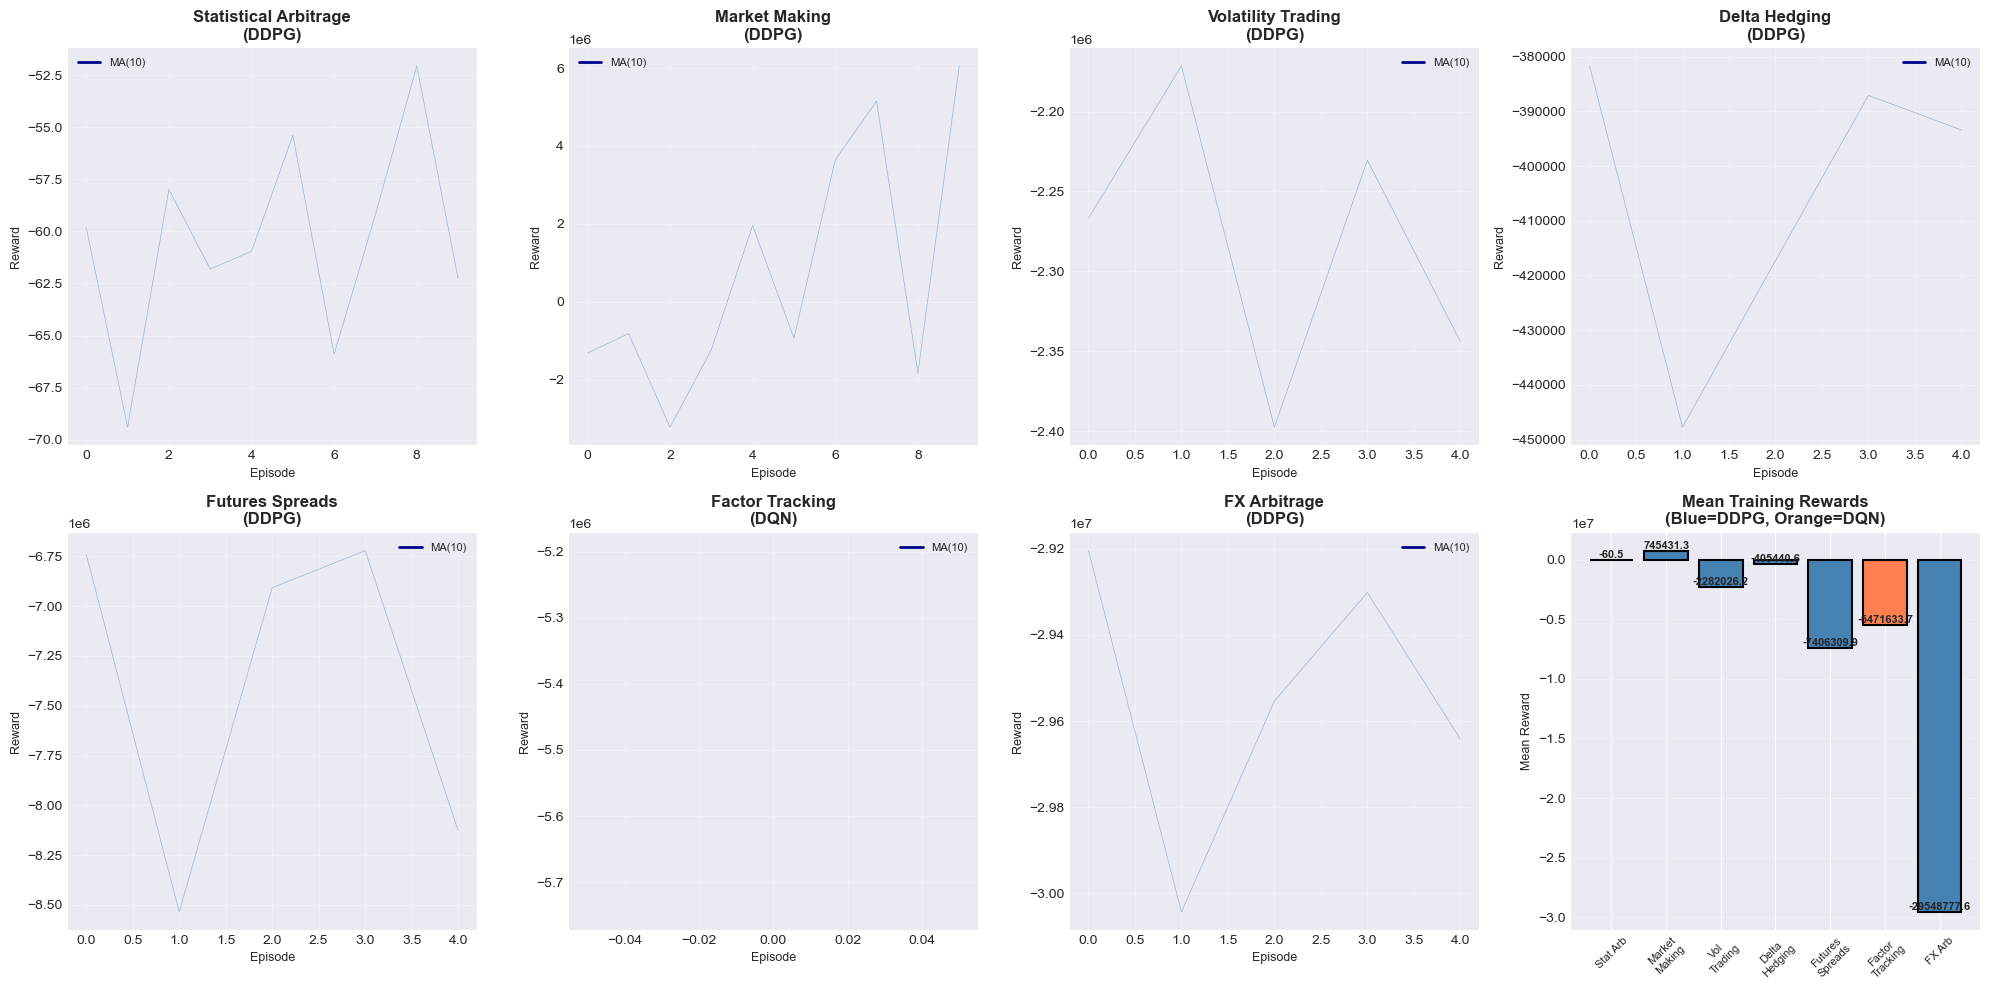


SPECIALIST TRAINING SUMMARY
Strategy                  Algorithm    Episodes     Mean Reward  Final Avg (10)
------------------------------------------------------------------------------------------
Statistical Arbitrage (DDPG) DDPG               10          -60.48          -60.48
Market Making (DDPG)      DDPG               10       745431.33       745431.33
Volatility Trading (DDPG) DDPG                5     -2282026.19     -2282026.19
Delta Hedging (DDPG)      DDPG                5      -405440.60      -405440.60
Futures Spreads (DDPG)    DDPG                5     -7406309.86     -7406309.86
Factor Tracking (DQN)     DQN                 1     -5471633.74     -5471633.74
FX Arbitrage (DDPG)       DDPG                5    -29548777.57    -29548777.57


In [64]:
# Collect all training rewards
all_rewards = {
    'Statistical Arbitrage\n(DDPG)': stat_arb_rewards,
    'Market Making\n(DDPG)': mm_rewards,
    'Volatility Trading\n(DDPG)': vol_agent.training_metrics['episode_rewards'],
    'Delta Hedging\n(DDPG)': delta_agent.training_metrics['episode_rewards'],
    'Futures Spreads\n(DDPG)': futures_agent.training_metrics['episode_rewards'],
    'Factor Tracking\n(DQN)': factor_rewards,
    'FX Arbitrage\n(DDPG)': fx_agent.training_metrics['episode_rewards']
}

# Create comparison plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, rewards) in enumerate(all_rewards.items()):
    ax = axes[idx]
    ax.plot(rewards, alpha=0.5, linewidth=0.5, color='steelblue')
    ax.plot(pd.Series(rewards).rolling(10).mean(), linewidth=2, color='darkblue', label='MA(10)')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode', fontsize=9)
    ax.set_ylabel('Reward', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Summary bar chart in last subplot
ax = axes[7]
mean_rewards = [np.mean(rewards) for rewards in all_rewards.values()]
names_short = ['Stat Arb', 'Market\nMaking', 'Vol\nTrading', 'Delta\nHedging', 
               'Futures\nSpreads', 'Factor\nTracking', 'FX Arb']
colors = ['steelblue']*6
colors[5] = 'coral'  # Highlight DQN in different color

bars = ax.bar(names_short, mean_rewards, color=colors, edgecolor='black', linewidth=1.5)
ax.set_title('Mean Training Rewards\n(Blue=DDPG, Orange=DQN)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Reward', fontsize=9)
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*90)
print("SPECIALIST TRAINING SUMMARY")
print("="*90)
print(f"{'Strategy':<25} {'Algorithm':<10} {'Episodes':>10} {'Mean Reward':>15} {'Final Avg (10)':>15}")
print("-"*90)
for name, rewards in all_rewards.items():
    name_clean = name.replace('\n', ' ')
    algo = 'DQN' if 'DQN' in name else 'DDPG'
    print(f"{name_clean:<25} {algo:<10} {len(rewards):>10} {np.mean(rewards):>15.2f} {np.mean(rewards[-10:]):>15.2f}")
print("="*90)

## 10. Save All Trained Models

Save all specialist agents for deployment in the hierarchical framework.

In [67]:
# Create models directory structure
specialists_dir = Path.cwd().parent / 'models' / 'specialists'
specialists_dir.mkdir(parents=True, exist_ok=True)

# Define specialist agents with their folder names
agents_to_save = {
    'statistical_arbitrage': ('statistical_arbitrage', stat_arb_agent, 'DDPG'),
    'market_making': ('market_making', mm_agent, 'DDPG'),
    'volatility_trading': ('volatility_trading', vol_agent, 'DDPG'),
    'delta_hedging': ('delta_hedging', delta_agent, 'DDPG'),
    'futures_spreads': ('futures_spreads', futures_agent, 'DDPG'),
    'factor_tracking': ('factor_tracking', factor_agent, 'DQN'),
    'fx_arbitrage': ('fx_arbitrage', fx_agent, 'DDPG')
}

print("Saving specialist models...\n")
saved_models = []

for key, (folder_name, agent, algo) in agents_to_save.items():
    # Create specialist folder
    specialist_dir = specialists_dir / folder_name
    specialist_dir.mkdir(exist_ok=True)
    
    # Save model in specialist folder
    model_path = specialist_dir / f'{folder_name}_{algo.lower()}.pt'
    agent.save(str(model_path))
    file_size = model_path.stat().st_size / 1024
    saved_models.append((folder_name, model_path, file_size))
    print(f"✓ Saved {folder_name:<25} → {specialist_dir.name}/{model_path.name} ({file_size:>8.2f} KB)")

print(f"\n{'='*80}")
print(f"✓ All {len(saved_models)} specialist models saved to their respective folders")
print(f"{'='*80}")

# Save metadata in main specialists directory
metadata_path = specialists_dir / 'training_metadata.txt'
with open(metadata_path, 'w') as f:
    f.write("SPECIALIST AGENTS TRAINING METADATA\n")
    f.write("="*80 + "\n\n")
    f.write(f"Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Total Agents: {len(agents_to_save)}\n\n")
    
    f.write("Directory Structure:\n")
    f.write("-"*80 + "\n")
    f.write("models/specialists/\n")
    for folder_name, _, algo in agents_to_save.values():
        f.write(f"  ├── {folder_name}/\n")
        f.write(f"  │   └── {folder_name}_{algo.lower()}.pt\n")
    f.write("\n")
    
    f.write("Agent Details:\n")
    f.write("-"*80 + "\n")
    for folder_name, agent, algo in agents_to_save.values():
        rewards = agent.training_metrics['episode_rewards']
        f.write(f"\n{folder_name}:\n")
        f.write(f"  Algorithm: {algo}\n")
        f.write(f"  Episodes Trained: {len(rewards)}\n")
        f.write(f"  Mean Reward: {np.mean(rewards):.2f}\n")
        f.write(f"  Final Avg (10): {np.mean(rewards[-10:]):.2f}\n")
        f.write(f"  Saved to: {folder_name}/{folder_name}_{algo.lower()}.pt\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("\nAlgorithm Mapping:\n")
    f.write("  - Statistical Arbitrage: DDPG (continuous position sizing)\n")
    f.write("  - Market Making: DDPG (continuous bid/ask quotes)\n")
    f.write("  - Volatility Trading: DDPG (continuous vega exposure)\n")
    f.write("  - Delta Hedging: DDPG (continuous hedge ratios)\n")
    f.write("  - Futures Spreads: DDPG (continuous spread positions)\n")
    f.write("  - Factor Tracking: DQN (discrete factor combinations)\n")
    f.write("  - FX Arbitrage: DDPG (continuous currency positions)\n")

print(f"\n✓ Metadata saved to: {metadata_path}")

Saving specialist models...

Model saved to c:\Users\kenne\Roadmap_to_PhD\The_Hierarchical_DRL_Multi_Strategy_Fund_Code\models\specialists\statistical_arbitrage\statistical_arbitrage_ddpg.pt
✓ Saved statistical_arbitrage     → statistical_arbitrage/statistical_arbitrage_ddpg.pt (  325.91 KB)
Model saved to c:\Users\kenne\Roadmap_to_PhD\The_Hierarchical_DRL_Multi_Strategy_Fund_Code\models\specialists\market_making\market_making_ddpg.pt
✓ Saved market_making             → market_making/market_making_ddpg.pt (  677.16 KB)
Model saved to c:\Users\kenne\Roadmap_to_PhD\The_Hierarchical_DRL_Multi_Strategy_Fund_Code\models\specialists\volatility_trading\volatility_trading_ddpg.pt
✓ Saved volatility_trading        → volatility_trading/volatility_trading_ddpg.pt (  329.84 KB)
Model saved to c:\Users\kenne\Roadmap_to_PhD\The_Hierarchical_DRL_Multi_Strategy_Fund_Code\models\specialists\delta_hedging\delta_hedging_ddpg.pt
✓ Saved delta_hedging             → delta_hedging/delta_hedging_ddpg.pt (  32